In [ ]:

# CELLULE 1 — IMPORTS & INSTALLATION


!pip install -q segmentation-models-pytorch albumentations

import os, glob, random, math, hashlib
from collections import Counter
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from PIL import Image as PILImage
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:0000:01
Device : cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB


In [ ]:

# CELLULE 2 — HYPERPARAMÈTRES


IMG_SIZE    = 256
BATCH_SIZE  = 8
ACCUM_STEPS = 4        # batch effectif = 32
EPOCHS      = 60
LR          = 3e-4
WEIGHT_DECAY= 1e-4
NUM_CLASSES = 4

# ── Loss multitask ─────────────────────────────────────────────────────────────
# Classification deja 99% donc  on lui donne moins de poids
# Segmentation a 0.86 soo c'est la qu'on veut progresser
W_SEG  = 0.65
W_CLS  = 0.35
W_DICE = 0.7
W_FOCAL= 0.3

# ── Early stopping DUAL ────────────────────────────────────────────────────────
# Segmentation : patience sur le Dice val
# Classification : s'arrête quand acc val >= seuil pendant N epochs
PATIENCE_SEG      = 15    # epochs sans amélioration Dice
PATIENCE_CLS_STOP = 5     # epochs consécutives où acc >= ACC_FREEZE_THRESH
ACC_FREEZE_THRESH = 0.985 # 98.5% → on gèle la tête classification

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CODE_TO_IDX = {'gl': 0, 'me': 1, 'no': 2, 'pi': 3}

BASE_BRISC     = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025'
SEG_TRAIN_IMG  = f'{BASE_BRISC}/segmentation_task/train/images'
SEG_TRAIN_MASK = f'{BASE_BRISC}/segmentation_task/train/masks'
SEG_TEST_IMG   = f'{BASE_BRISC}/segmentation_task/test/images'
SEG_TEST_MASK  = f'{BASE_BRISC}/segmentation_task/test/masks'

print('Config OK')
print(f'  Batch effectif : {BATCH_SIZE}×{ACCUM_STEPS}={BATCH_SIZE*ACCUM_STEPS}')
print(f'  W_SEG={W_SEG} | W_CLS={W_CLS}')
print(f'  Early stop seg : patience={PATIENCE_SEG}')
print(f'  Early stop cls : gèle quand acc>={ACC_FREEZE_THRESH} pendant {PATIENCE_CLS_STOP} epochs')

Config OK
  Batch effectif : 8×4=32
  W_SEG=0.65 | W_CLS=0.35
  Early stop seg : patience=15
  Early stop cls : gèle quand acc>=0.985 pendant 5 epochs


In [ ]:
 
# CELLULE 3 — DATASET CLEANING BRISC


def compute_md5(filepath):
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

def extract_class_from_filename(fname):
    parts = fname.replace('.jpg','').replace('.png','').split('_')
    if len(parts) >= 4:
        code = parts[3]
        if code in CODE_TO_IDX:
            return code, CODE_TO_IDX[code]
    return None, None

def collect_brisc(img_dir, mask_dir, split_name):
    data  = []
    stats = {'total':0,'no_class':0,'no_mask':0,'corrupt':0,'empty_mask':0,'valid':0}

    img_files  = sorted([f for f in os.listdir(img_dir)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    mask_index = {mf.rsplit('.',1)[0]: os.path.join(mask_dir, mf)
                  for mf in os.listdir(mask_dir)}

    for fname in img_files:
        stats['total'] += 1
        stem     = fname.rsplit('.',1)[0]
        img_path = os.path.join(img_dir, fname)

        code, cls_idx = extract_class_from_filename(fname)
        if cls_idx is None:
            stats['no_class'] += 1; continue

        if stem not in mask_index:
            stats['no_mask'] += 1; continue
        mask_path = mask_index[stem]

        try:
            img_check = PILImage.open(img_path); img_check.verify()
        except:
            stats['corrupt'] += 1; continue

        mask_arr    = np.array(PILImage.open(mask_path).convert('L'))
        tumor_ratio = (mask_arr > 127).mean()
        is_empty    = tumor_ratio == 0
        if is_empty:
            stats['empty_mask'] += 1

        stats['valid'] += 1
        data.append({
            'img_path'   : img_path,
            'mask_path'  : mask_path,
            'cls_idx'    : cls_idx,
            'cls_name'   : CLASS_NAMES[cls_idx],
            'md5'        : compute_md5(img_path),
            'tumor_ratio': tumor_ratio,
            'empty_mask' : is_empty,
        })

    print(f'BRISC {split_name} — valid:{stats["valid"]} | corrupt:{stats["corrupt"]} '
          f'| empty_mask:{stats["empty_mask"]} | no_mask:{stats["no_mask"]}')
    return data


print('=== Collecte BRISC ===')
brisc_train_raw = collect_brisc(SEG_TRAIN_IMG, SEG_TRAIN_MASK, 'train')
brisc_test_raw  = collect_brisc(SEG_TEST_IMG,  SEG_TEST_MASK,  'test')

# ── Détecter data leakage ─────────────────────────────────────────────────────
# hna win yt3awdou les imgs de train f test 
train_md5s = {d['md5'] for d in brisc_train_raw}
test_md5s  = {d['md5'] for d in brisc_test_raw}
leakage    = train_md5s & test_md5s
print(f'\nData leakage détecté : {len(leakage)} images')

# Retire les images leakées du test
brisc_test_clean = [d for d in brisc_test_raw if d['md5'] not in leakage]
print(f'Test après nettoyage : {len(brisc_test_clean)} images')

# Distribution classes
print('\n=== Distribution classes (train) ===')
for cls in CLASS_NAMES:
    cnt   = sum(1 for d in brisc_train_raw if d['cls_name']==cls)
    empty = sum(1 for d in brisc_train_raw if d['cls_name']==cls and d['empty_mask'])
    print(f'  {cls:15s}: {cnt:4d} total | {empty:4d} masques vides')

=== Collecte BRISC ===
BRISC train — valid:3933 | corrupt:0 | empty_mask:0 | no_mask:0
BRISC test — valid:860 | corrupt:0 | empty_mask:0 | no_mask:0

Data leakage détecté : 7 images
Test après nettoyage : 853 images

=== Distribution classes (train) ===
  glioma         : 1147 total |    0 masques vides
  meningioma     : 1329 total |    0 masques vides
  notumor        :    0 total |    0 masques vides
  pituitary      : 1457 total |    0 masques vides


In [ ]:

# CELLULE 4 — SPLIT TRAIN / VAL


labels_for_split = [d['cls_idx'] for d in brisc_train_raw]
train_split, val_split = train_test_split(
    brisc_train_raw, test_size=0.15,
    stratify=labels_for_split, random_state=42)

print(f'Train : {len(train_split)} | Val : {len(val_split)} | Test : {len(brisc_test_clean)}')

print('\nDistribution val :')
val_cls = Counter(d['cls_name'] for d in val_split)
for cls, cnt in sorted(val_cls.items()):
    print(f'  {cls:15s}: {cnt}')

Train : 3343 | Val : 590 | Test : 853

Distribution val :
  glioma         : 172
  meningioma     : 199
  pituitary      : 219


In [ ]:

# CELLULE 5 — TRANSFORMS


train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.1, scale=(0.85,1.15), rotate=(-20,20), p=0.6),
    A.ElasticTransform(alpha=120, sigma=6, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.2),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

print('Transforms OK')

Transforms OK


In [ ]:

# CELLULE 6 — DATASET CLASS


class MultitaskBrainDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data      = data_list
        self.transform = transform

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img  = np.array(PILImage.open(item['img_path']).convert('RGB'))
        mask = np.array(PILImage.open(item['mask_path']).convert('L'))
        mask = (mask > 127).astype(np.float32)
        cls_label = torch.tensor(item['cls_idx'], dtype=torch.long)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].unsqueeze(0)

        return img, mask, cls_label

print('Dataset class OK')

Dataset class OK


In [ ]:

# CELLULE 7 — DATALOADERS + OVERSAMPLING


def compute_sample_weights(data_list):
    """Surpondère les petites tumeurs pour réduire les cas Dice=0."""
    weights = []
    for item in data_list:
        ratio = item['tumor_ratio']
        if item['cls_name'] == 'notumor':
            w = 1.0
        elif ratio < 0.02:
            w = 5.0   # très petite tumeur
        elif ratio < 0.05:
            w = 2.0   # petite tumeur
        else:
            w = 1.0
        weights.append(w)
    return torch.DoubleTensor(weights)

print('Calcul oversampling weights...')
train_weights = compute_sample_weights(train_split)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights), replacement=True)

train_ds = MultitaskBrainDataset(train_split, transform=train_transform)
val_ds   = MultitaskBrainDataset(val_split,   transform=val_transform)
test_ds  = MultitaskBrainDataset(brisc_test_clean, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Calcul oversampling weights...
Train: 3343 | Val: 590 | Test: 853


In [ ]:

# CELLULE 8 — MODÈLE MULTITASK (EfficientNet-B4 + scSE)


class MultitaskBrainModel(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()

        # ── U-Net EfficientNet-B4 + attention scSE ────────────────────────────
        self.unet = smp.Unet(
            encoder_name          = 'efficientnet-b4',
            encoder_weights       = 'imagenet',
            in_channels           = 3,
            classes               = 1,
            activation            = None,
            decoder_use_batchnorm = True,
            decoder_attention_type= 'scse',
        )

        # EfficientNet-B4  dernier bloc = 1792 channels
        enc_channels = self.unet.encoder.out_channels[-1]

        # ── Tête classification ───────────────────────────────────────────────
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(enc_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(512, num_classes)
        )

        for m in self.cls_head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        features       = self.unet.encoder(x)
        decoder_output = self.unet.decoder(features)
        seg_logits     = self.unet.segmentation_head(decoder_output)
        cls_logits     = self.cls_head(features[-1])
        return seg_logits, cls_logits

    def freeze_cls_head(self):
        """Gèle la tête classification — plus de gradient pour cls."""
        for p in self.cls_head.parameters():
            p.requires_grad = False
        print('  [Early Stop CLS] Tête classification gelée')

    def unfreeze_cls_head(self):
        for p in self.cls_head.parameters():
            p.requires_grad = True


model = MultitaskBrainModel(num_classes=NUM_CLASSES).to(DEVICE)

# Test forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    seg_out, cls_out = model(dummy)
    print(f'Seg output : {seg_out.shape}')
    print(f'Cls output : {cls_out.shape}')

total = sum(p.numel() for p in model.parameters())
print(f'Paramètres : {total:,}')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Seg output : torch.Size([2, 1, 256, 256])
Cls output : torch.Size([2, 4])
Paramètres : 20,535,058


In [ ]:

# CELLULE 9 — LOSS + MÉTRIQUES


dice_loss_fn  = smp.losses.DiceLoss(mode='binary', from_logits=True)
focal_loss_fn = smp.losses.FocalLoss(mode='binary')
ce_loss_fn    = nn.CrossEntropyLoss()


def combined_loss(seg_logits, seg_masks, cls_logits, cls_labels, cls_frozen=False):
    l_seg = W_DICE * dice_loss_fn(seg_logits, seg_masks) + \
            W_FOCAL * focal_loss_fn(seg_logits, seg_masks)

    if cls_frozen:
        # Tête cls gelée → on n'inclut pas la loss cls dans le total
        return W_SEG * l_seg, l_seg.item(), 0.0

    l_cls   = ce_loss_fn(cls_logits, cls_labels)
    l_total = W_SEG * l_seg + W_CLS * l_cls
    return l_total, l_seg.item(), l_cls.item()


def dice_score(pred_logits, masks, threshold=0.5):
    preds  = (torch.sigmoid(pred_logits) > threshold).float()
    smooth = 1e-6
    inter  = (preds * masks).sum(dim=(1,2,3))
    union  = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
    return ((2.0 * inter + smooth) / (union + smooth)).mean().item()


def iou_score(pred_logits, masks, threshold=0.5):
    preds  = (torch.sigmoid(pred_logits) > threshold).float()
    smooth = 1e-6
    inter  = (preds * masks).sum(dim=(1,2,3))
    union  = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()


def accuracy(cls_logits, cls_labels):
    return (cls_logits.argmax(dim=1) == cls_labels).float().mean().item()


print('Loss + métriques OK')

Loss + métriques OK


In [ ]:

# CELLULE 10 — TRAINING LOOP


scaler = GradScaler()   # Mixed Precision

def train_one_epoch(model, loader, optimizer, cls_frozen=False):
    model.train()
    total_loss = total_dice = total_acc = n = 0
    optimizer.zero_grad()
    pbar = tqdm(enumerate(loader), total=len(loader), desc='  Train', leave=False)

    for step, (imgs, masks, labels) in pbar:
        imgs, masks, labels = imgs.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)

        with autocast():
            seg_logits, cls_logits = model(imgs)
            loss, _, _ = combined_loss(seg_logits, masks, cls_logits, labels, cls_frozen)

        scaler.scale(loss / ACCUM_STEPS).backward()

        if (step+1) % ACCUM_STEPS == 0 or (step+1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item()
        total_dice += dice_score(seg_logits.detach().float(), masks)
        total_acc  += accuracy(cls_logits.detach().float(), labels)
        n          += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'dice': f'{total_dice/n:.4f}',
                          'acc' : f'{total_acc/n:.4f}'})

    return total_loss/n, total_dice/n, total_acc/n


@torch.no_grad()
def evaluate(model, loader, desc='  Val', cls_frozen=False):
    model.eval()
    total_loss = total_dice = total_iou = total_acc = n = 0

    for imgs, masks, labels in tqdm(loader, desc=desc, leave=False):
        imgs, masks, labels = imgs.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)

        with autocast():
            seg_logits, cls_logits = model(imgs)
            loss, _, _ = combined_loss(seg_logits, masks, cls_logits, labels, cls_frozen)

        total_loss += loss.item()
        total_dice += dice_score(seg_logits.float(), masks)
        total_iou  += iou_score(seg_logits.float(), masks)
        total_acc  += accuracy(cls_logits.float(), labels)
        n          += 1

    return total_loss/n, total_dice/n, total_iou/n, total_acc/n


print('Training loop OK')

Training loop OK


/tmp/ipykernel_55/887624417.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()   # Mixed Precision


In [ ]:

# CELLULE 11 — ENTRAÎNEMENT PRINCIPAL (dual early stopping)


optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {
    'train_loss':[], 'train_dice':[], 'train_acc':[],
    'val_loss':[], 'val_dice':[], 'val_iou':[], 'val_acc':[]
}

best_val_dice    = 0.0
patience_seg_ctr = 0   # early stop segmentation
patience_cls_ctr = 0   # early stop classification
cls_frozen       = False
best_model_path  = '/kaggle/working/multitask_best.pth'

print(f'=== Entraînement ({EPOCHS} epochs max) ===')
print(f'Early stop SEG : patience={PATIENCE_SEG}')
print(f'Early stop CLS : gèle si acc>={ACC_FREEZE_THRESH} pendant {PATIENCE_CLS_STOP} epochs\n')

for epoch in range(1, EPOCHS+1):

    tr_loss, tr_dice, tr_acc     = train_one_epoch(model, train_loader, optimizer, cls_frozen)
    scheduler.step()
    v_loss, v_dice, v_iou, v_acc = evaluate(model, val_loader, cls_frozen=cls_frozen)

    history['train_loss'].append(tr_loss)
    history['train_dice'].append(tr_dice)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_dice)
    history['val_iou'].append(v_iou)
    history['val_acc'].append(v_acc)

    cls_status = '[CLS FROZEN]' if cls_frozen else ''
    print(f'Ep {epoch:3d}/{EPOCHS} {cls_status} | '
          f'Tr Loss {tr_loss:.4f} Dice {tr_dice:.4f} Acc {tr_acc:.4f} | '
          f'Val Loss {v_loss:.4f} Dice {v_dice:.4f} IoU {v_iou:.4f} Acc {v_acc:.4f}',
          end='')

    # ── Early stop SEGMENTATION ───────────────────────────────────────────────
    if v_dice > best_val_dice:
        best_val_dice    = v_dice
        patience_seg_ctr = 0
        torch.save(model.state_dict(), best_model_path)
        print('  ✓', end='')
    else:
        patience_seg_ctr += 1
        if patience_seg_ctr >= PATIENCE_SEG:
            print(f'\n  [Early Stop SEG] Pas d\'amélioration Dice depuis {PATIENCE_SEG} epochs')
            break

    # ── Early stop CLASSIFICATION ─────────────────────────────────────────────
    if not cls_frozen:
        if v_acc >= ACC_FREEZE_THRESH:
            patience_cls_ctr += 1
            if patience_cls_ctr >= PATIENCE_CLS_STOP:
                model.freeze_cls_head()
                cls_frozen = True
                # Reconfigure optimizer sans les params cls gelés
                optimizer = optim.AdamW(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=LR, weight_decay=WEIGHT_DECAY)
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS-epoch, eta_min=1e-6)
        else:
            patience_cls_ctr = 0   # reset si acc redescend

    print()

print(f'\nMeilleur Val Dice : {best_val_dice:.4f}')

=== Entraînement (60 epochs max) ===
Early stop SEG : patience=15
Early stop CLS : gèle si acc>=0.985 pendant 5 epochs



  Train:   0%|          | 0/418 [00:00<?, ?it/s]/tmp/ipykernel_55/887624417.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
  Val:   0%|          | 0/74 [00:00<?, ?it/s]                                                   /tmp/ipykernel_55/887624417.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                      

Ep   1/60  | Tr Loss 0.7114 Dice 0.2167 Acc 0.6956 | Val Loss 0.3861 Dice 0.6502 IoU 0.5315 Acc 0.8930  ✓


Ep   2/60  | Tr Loss 0.3689 Dice 0.6338 Acc 0.8328 | Val Loss 0.1971 Dice 0.7107 IoU 0.6214 Acc 0.9510  ✓


Ep   3/60  | Tr Loss 0.2596 Dice 0.6931 Acc 0.8633 | Val Loss 0.1532 Dice 0.7444 IoU 0.6501 Acc 0.9645  ✓


...

Ep  56/60 [CLS FROZEN] | Tr Loss 0.0608 Dice 0.8460 Acc 0.9659 | Val Loss 0.0540 Dice 0.8751 IoU 0.8038 Acc 0.9764  ✓


Ep  57/60 [CLS FROZEN] | Tr Loss 0.0597 Dice 0.8461 Acc 0.9626 | Val Loss 0.0543 Dice 0.8734 IoU 0.8019 Acc 0.9747


Ep  58/60 [CLS FROZEN] | Tr Loss 0.0618 Dice 0.8445 Acc 0.9650 | Val Loss 0.0541 Dice 0.8728 IoU 0.8014 Acc 0.9747


Ep  59/60 [CLS FROZEN] | Tr Loss 0.0628 Dice 0.8405 Acc 0.9704 | Val Loss 0.0539 Dice 0.8733 IoU 0.8019 Acc 0.9747


Ep  60/60 [CLS FROZEN] | Tr Loss 0.0626 Dice 0.8448 Acc 0.9635 | Val Loss 0.0538 Dice 0.8735 IoU 0.8023 Acc 0.9747

Meilleur Val Dice : 0.8751


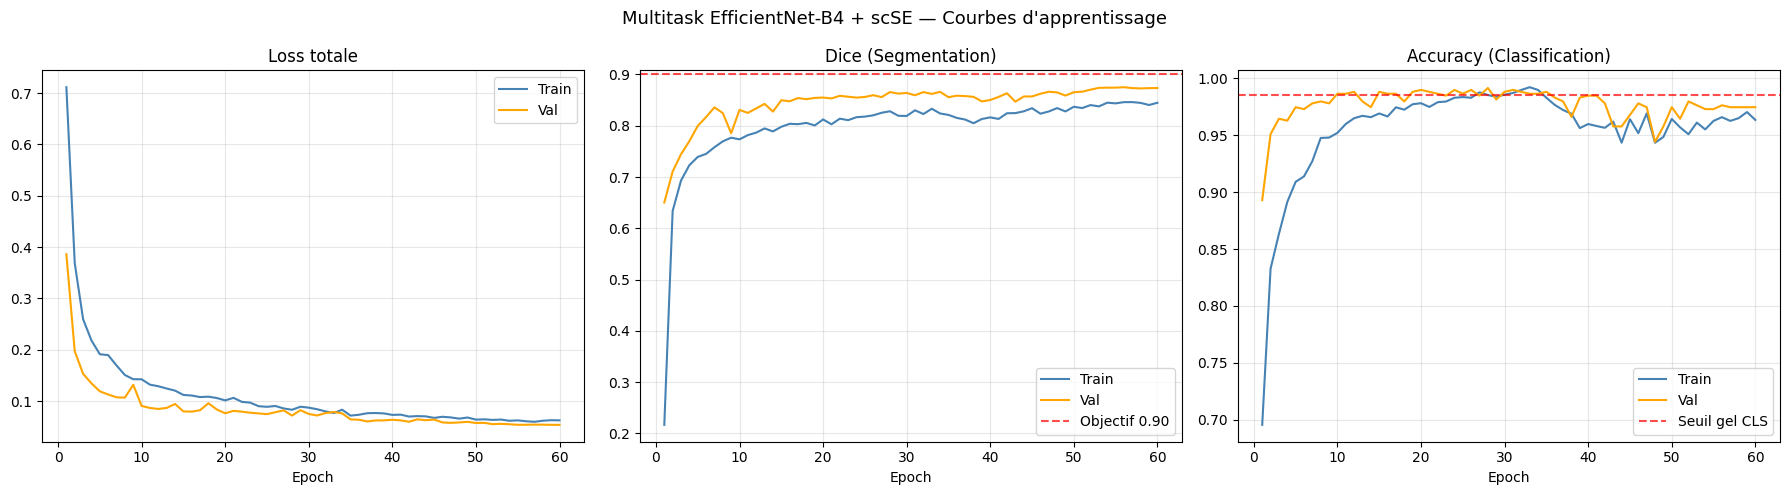

In [ ]:

# CELLULE 12 — COURBES D'APPRENTISSAGE


epochs_range = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multitask EfficientNet-B4 + scSE — Courbes d\'apprentissage', fontsize=13)

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='orange')
axes[0].set_title('Loss totale'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_dice'], label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_dice'],   label='Val',   color='orange')
axes[1].axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='Objectif 0.90')
axes[1].set_title('Dice (Segmentation)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['train_acc'], label='Train', color='steelblue')
axes[2].plot(epochs_range, history['val_acc'],   label='Val',   color='orange')
axes[2].axhline(y=0.985, color='red', linestyle='--', alpha=0.7, label='Seuil gel CLS')
axes[2].set_title('Accuracy (Classification)'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/multitask_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

# CELLULE 13 — ÉVALUATION FINALE TEST SET


model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

test_loss, test_dice, test_iou, test_acc = evaluate(
    model, test_loader, desc='  Test', cls_frozen=cls_frozen)

print('═' * 55)
print('  RÉSULTATS FINAUX — TEST SET')
print('═' * 55)
print(f'  Dice Score    : {test_dice:.4f}   (objectif ≥ 0.90)')
print(f'  IoU Score     : {test_iou:.4f}')
print(f'  Accuracy Cls  : {test_acc:.4f}   (objectif ≥ 0.95)')
print('═' * 55)

  Test:   0%|          | 0/107 [00:00<?, ?it/s]/tmp/ipykernel_55/887624417.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                         

═══════════════════════════════════════════════════════
  RÉSULTATS FINAUX — TEST SET
═══════════════════════════════════════════════════════
  Dice Score    : 0.8699   (objectif ≥ 0.90)
  IoU Score     : 0.8007
  Accuracy Cls  : 0.9790   (objectif ≥ 0.95)
═══════════════════════════════════════════════════════


Collecte prédictions:   0%|          | 0/107 [00:00<?, ?it/s]/tmp/ipykernel_55/3515422254.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Collecte prédictions: 100%|██████████| 107/107 [00:05<00:00, 18.11it/s]



Rapport de classification :
              precision    recall  f1-score   support

      glioma       1.00      0.96      0.98       254
  meningioma       0.97      0.98      0.98       304
     notumor       0.00      0.00      0.00         0
   pituitary       0.97      1.00      0.98       295

    accuracy                           0.98       853
   macro avg       0.73      0.73      0.73       853
weighted avg       0.98      0.98      0.98       853



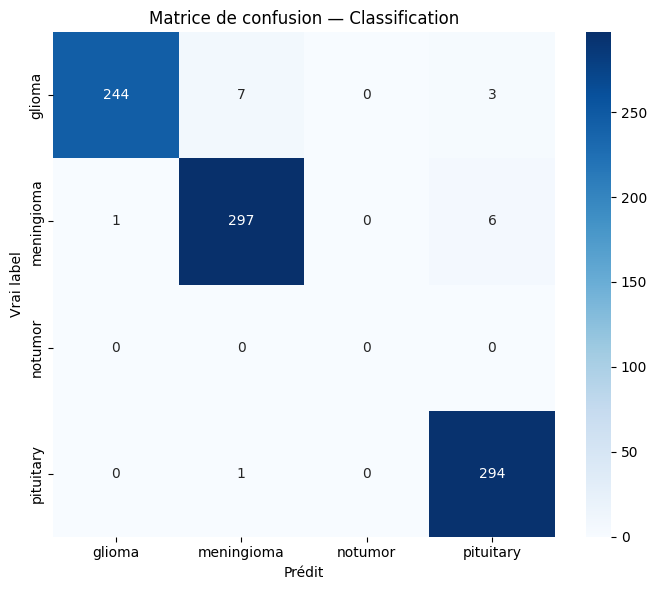

In [ ]:

# CELLULE 14 — RAPPORT DE CLASSIFICATION (bug ValueError fixé)


all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, masks, labels in tqdm(test_loader, desc='Collecte prédictions'):
        with autocast():
            _, cls_logits = model(imgs.to(DEVICE))
        all_preds.extend(cls_logits.float().argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Fix : labels=[0,1,2,3] force sklearn à afficher les 4 classes
# même si certaines n'apparaissent pas dans ce batch de test
print('\nRapport de classification :')
print(classification_report(
    all_labels, all_preds,
    labels=[0, 1, 2, 3],           # ← fix du ValueError
    target_names=CLASS_NAMES,
    zero_division=0
))

# ── Matrice de confusion ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Matrice de confusion — Classification')
ax.set_ylabel('Vrai label'); ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig('/kaggle/working/multitask_confusion_matrix.png', dpi=150)
plt.show()

/tmp/ipykernel_55/2209210764.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


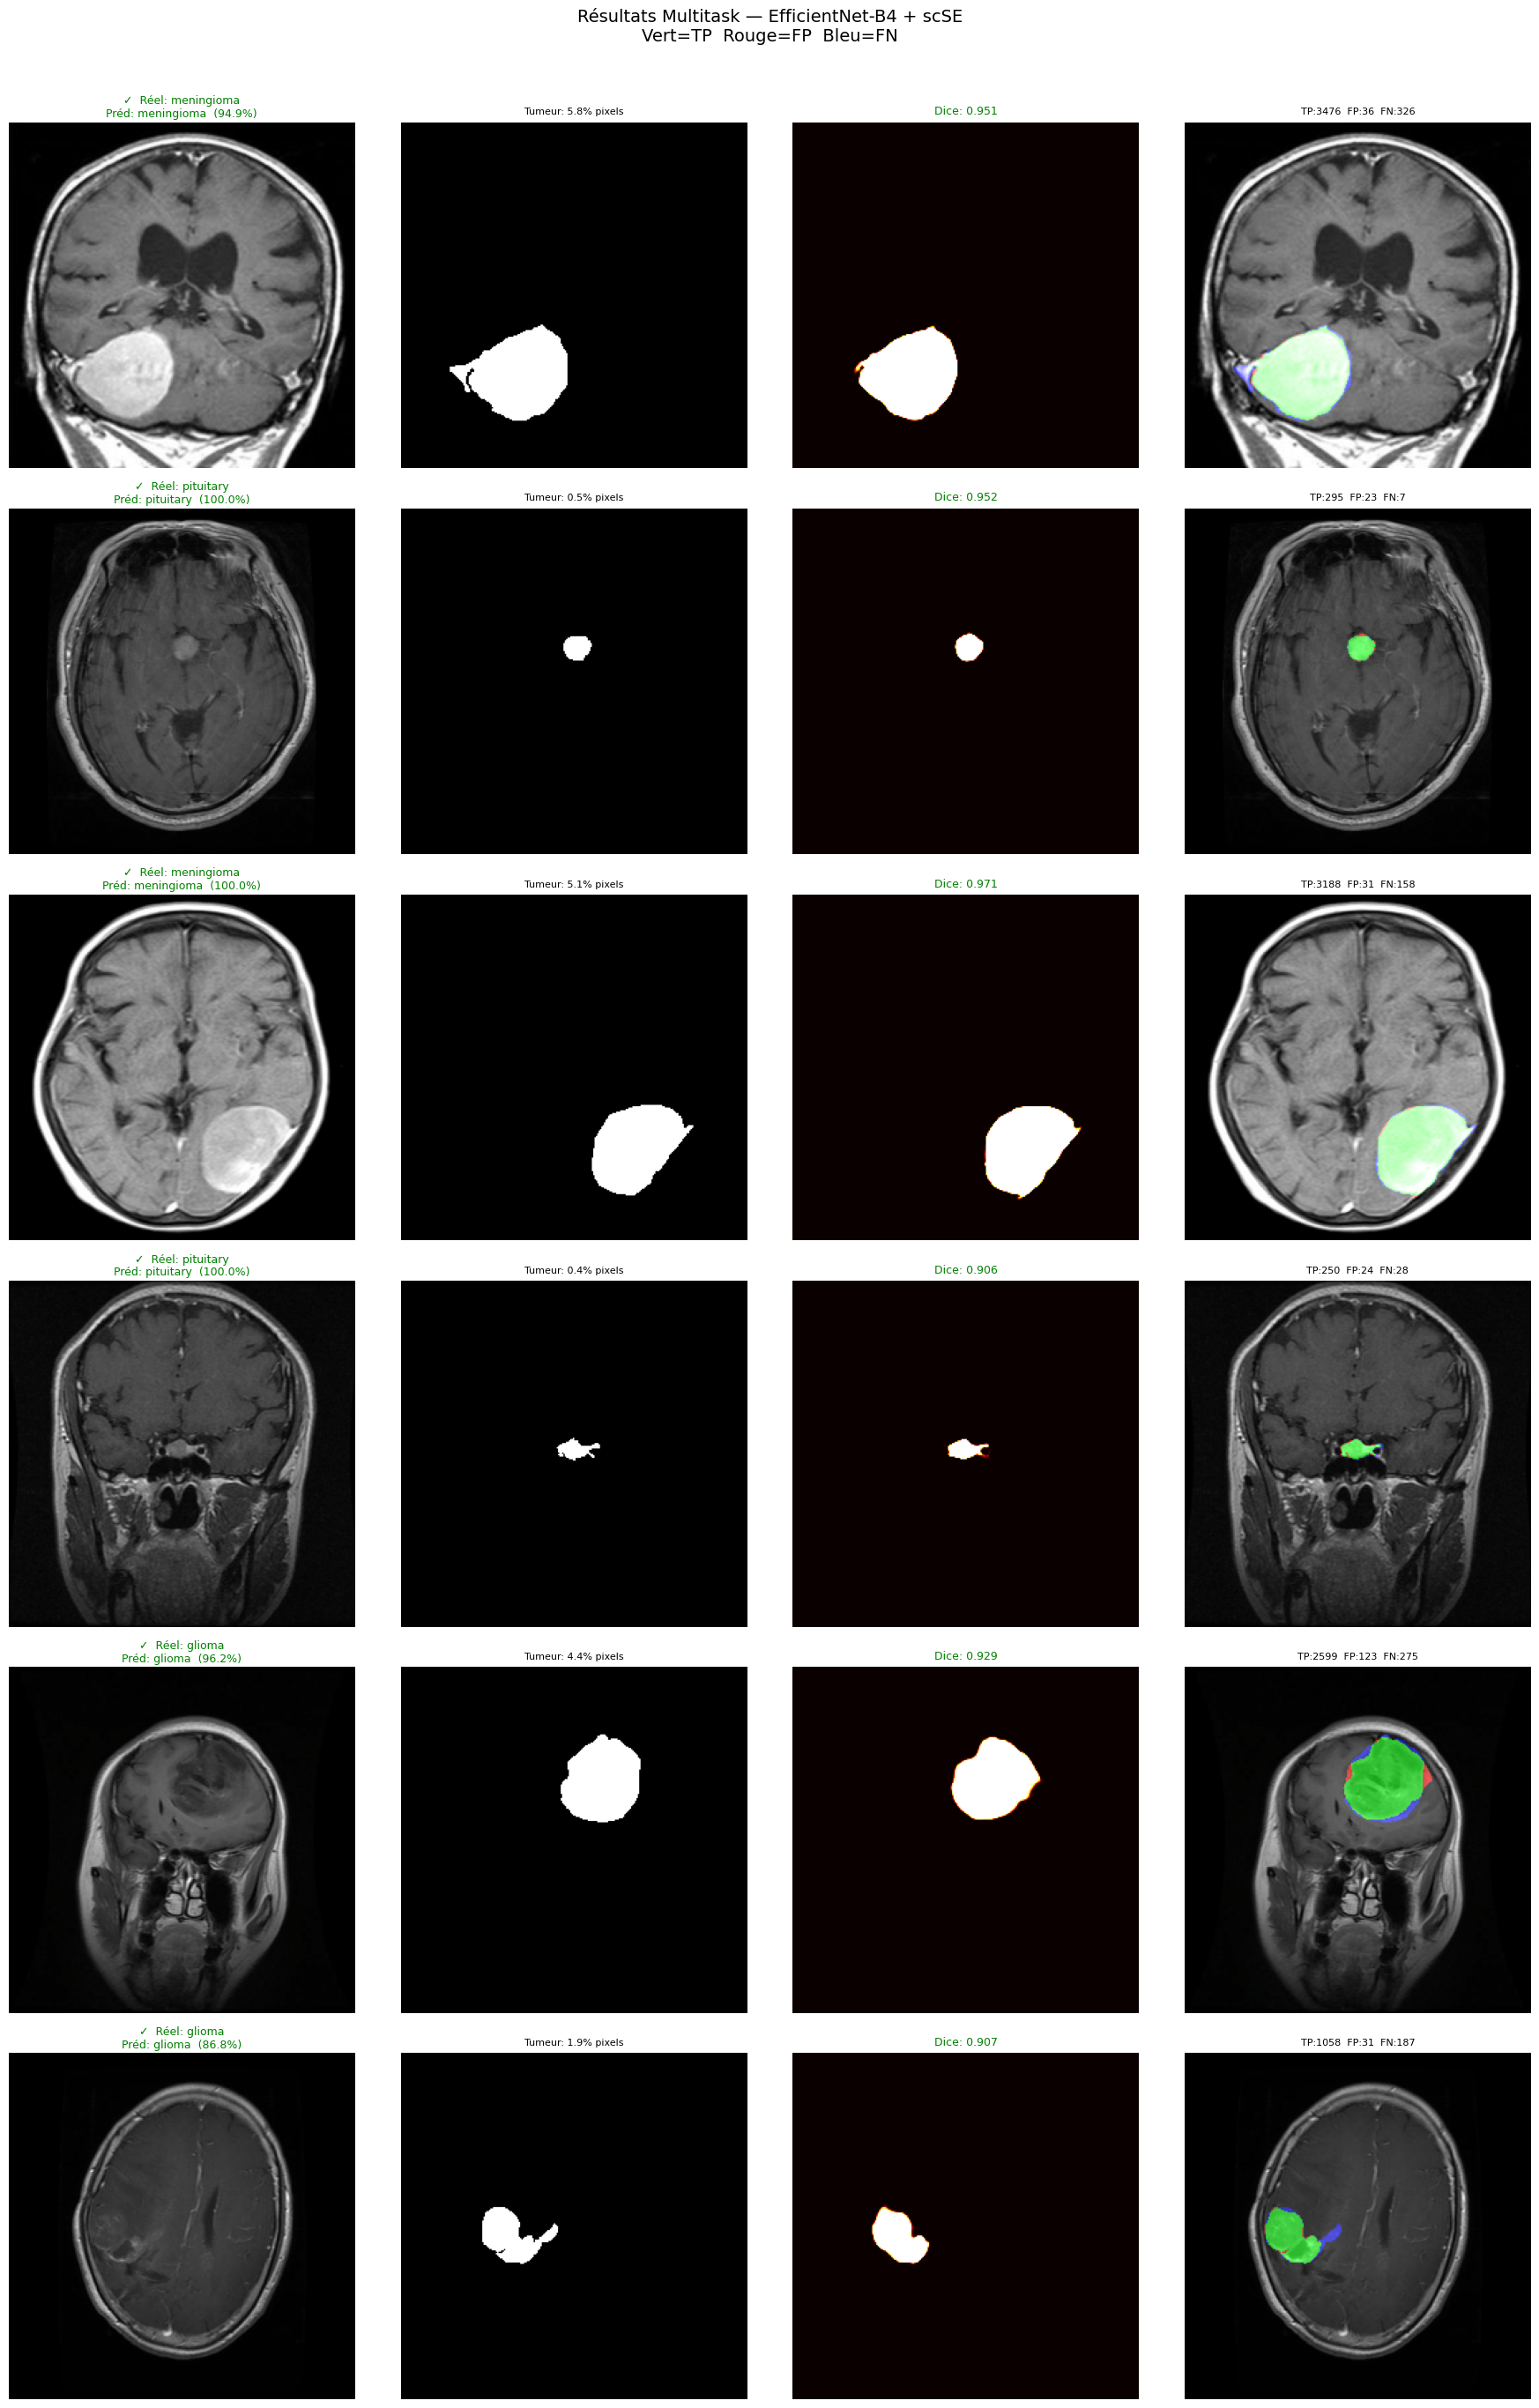

Visualisation sauvegardée


In [ ]:

# CELLULE 15 — VISUALISATION MULTITASK COMPLÈTE


def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()


def visualize_multitask(model, dataset, num_samples=8, threshold=0.5):
    model.eval()

    # Sélection  on prend des samples variés par classe
    by_class = {i: [] for i in range(NUM_CLASSES)}
    for idx in range(len(dataset)):
        _, _, lbl = dataset[idx]
        by_class[lbl.item()].append(idx)

    # 2 samples par classe si possible
    indices = []
    per_cls = max(1, num_samples // NUM_CLASSES)
    for cls_idx in range(NUM_CLASSES):
        pool = by_class[cls_idx]
        indices += random.sample(pool, min(per_cls, len(pool)))
    indices = indices[:num_samples]
    random.shuffle(indices)

    fig, axes = plt.subplots(len(indices), 4, figsize=(18, len(indices) * 4.5))
    fig.suptitle('Résultats Multitask — EfficientNet-B4 + scSE\n'
                 'Vert=TP  Rouge=FP  Bleu=FN', fontsize=14, y=1.01)

    col_titles = ['Image IRM', 'Masque réel', 'Masque prédit', 'Overlay']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_t, mask_t, cls_label = dataset[idx]
            inp = img_t.unsqueeze(0).to(DEVICE)

            with autocast():
                seg_logit, cls_logit = model(inp)

            # ── Segmentation ──────────────────────────────────────────────────
            seg_prob = torch.sigmoid(seg_logit[0,0].float()).cpu().numpy()
            seg_pred = (seg_prob > threshold).astype(np.uint8)
            mask_gt  = mask_t[0].numpy().astype(np.uint8)

            inter    = (seg_pred * mask_gt).sum()
            union    = seg_pred.sum() + mask_gt.sum()
            dice_val = (2 * inter + 1e-6) / (union + 1e-6)

            # ── Classification ────────────────────────────────────────────────
            probs    = torch.softmax(cls_logit.float(), dim=1)[0].cpu().numpy()
            cls_pred = probs.argmax()
            cls_conf = probs[cls_pred]
            cls_true = cls_label.item()
            correct  = '✓' if cls_pred == cls_true else '✗'

            img_display = denormalize(img_t)

            # Col 0 — Image + info classification
            axes[row,0].imshow(img_display)
            color_title = 'green' if cls_pred == cls_true else 'red'
            axes[row,0].set_title(
                f'{correct}  Réel: {CLASS_NAMES[cls_true]}\n'
                f'Préd: {CLASS_NAMES[cls_pred]}  ({cls_conf*100:.1f}%)',
                fontsize=9, color=color_title, pad=4)

            # Col 1 — Masque réel
            axes[row,1].imshow(mask_gt, cmap='gray', vmin=0, vmax=1)
            tumor_pct = mask_gt.mean() * 100
            axes[row,1].set_title(f'Tumeur: {tumor_pct:.1f}% pixels', fontsize=8)

            # Col 2 — Masque prédit + heatmap confiance
            axes[row,2].imshow(seg_prob, cmap='hot', vmin=0, vmax=1)
            axes[row,2].set_title(f'Dice: {dice_val:.3f}', fontsize=9,
                                   color='green' if dice_val > 0.7 else
                                         'orange' if dice_val > 0.3 else 'red')

            # Col 3 — Overlay TP/FP/FN
            overlay = img_display.copy()
            tp = seg_pred.astype(bool) & mask_gt.astype(bool)
            fp = seg_pred.astype(bool) & ~mask_gt.astype(bool)
            fn = ~seg_pred.astype(bool) & mask_gt.astype(bool)
            overlay[tp, 1] = np.clip(overlay[tp, 1] + 0.55, 0, 1)  # vert
            overlay[fp, 0] = np.clip(overlay[fp, 0] + 0.55, 0, 1)  # rouge
            overlay[fn, 2] = np.clip(overlay[fn, 2] + 0.55, 0, 1)  # bleu
            axes[row,3].imshow(overlay)
            axes[row,3].set_title(
                f'TP:{tp.sum()}  FP:{fp.sum()}  FN:{fn.sum()}', fontsize=8)

            # Barre de confiance par classe sous col 0
            ax_bar = axes[row,0]
            for col in range(4):
                axes[row,col].axis('off')

    plt.tight_layout()
    plt.savefig('/kaggle/working/multitask_visualization.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Visualisation sauvegardée')


visualize_multitask(model, test_ds, num_samples=8)

In [ ]:

# CELLULE 16 — SAUVEGARDE FINALE


SAVE_PATH = '/kaggle/working/multitask_final.pth'

torch.save({
    'model_state_dict' : model.state_dict(),
    'best_val_dice'    : round(best_val_dice, 4),
    'test_dice'        : round(test_dice, 4),
    'test_iou'         : round(test_iou,  4),
    'test_acc'         : round(test_acc,  4),
    'cls_was_frozen'   : cls_frozen,
    'history'          : history,
    'config': {
        'encoder'    : 'efficientnet-b4',
        'num_classes': NUM_CLASSES,
        'img_size'   : IMG_SIZE,
        'class_names': CLASS_NAMES,
        'W_SEG'      : W_SEG,
        'W_CLS'      : W_CLS,
    }
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'Modèle sauvegardé → {SAVE_PATH} ({size_mb:.1f} MB)')
print(f'  Val Dice  : {best_val_dice:.4f}')
print(f'  Test Dice : {test_dice:.4f}')
print(f'  Test IoU  : {test_iou:.4f}')
print(f'  Test Acc  : {test_acc*100:.1f}%')
print(f'  CLS gelée : {cls_frozen}')

Modèle sauvegardé → /kaggle/working/multitask_final.pth (83.0 MB)
  Val Dice  : 0.8751
  Test Dice : 0.8699
  Test IoU  : 0.8007
  Test Acc  : 97.9%
  CLS gelée : True
